# Sérsic modelling of BCG and ICL components from IFU data

In [ ]:
import astrophot as ap
import numpy as np
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.io import fits

In [ ]:
path = Path("~/data/ifu/2025-07-24/").expanduser()

In [ ]:
def bootstrap_fit(data, mask, target, weight, initial_params):
    bins = target._bins.detach().cpu().numpy()
    bin_ids = target._bin_ids.detach().cpu().numpy()
    bin_ids_sample = np.random.choice(bin_ids, len(bin_ids), replace=True)
    bootstrap_weight = np.zeros_like(weight)
    for bin_id in bin_ids_sample:
        bin_mask = bins == bin_id
        bootstrap_weight[bin_mask] += weight[bin_mask]
    bootstrap_mask = mask | (bootstrap_weight < 1e-6)
    bootstrap_weight[bootstrap_mask] = np.nan
    if target.has_psf:
        psf = target.psf
    else:
        psf = None
    bootstrap_target = ap.image.Target_Image(
        data=data,
        mask=bootstrap_mask,
        weight=bootstrap_weight,
        bins=bins,
        pixelscale=1,
        psf=psf,
    )
    bootstrap_model = ap.models.AstroPhot_Model(
        name="bootstrap",
        model_type="sersic galaxy model",
        parameters=initial_params,
        target=bootstrap_target,
        psf_mode="full" if psf is not None else "none",
    )
    bootstrap_model.initialize()
    ap.fit.LM(bootstrap_model).fit()
    return bootstrap_model.parameters.vector_values().detach().cpu().numpy()


def uncertainty_via_bootstrap(
    data,
    mask,
    target,
    weight,
    initial_params,
    model_to_update=None,
    n_bootstrap=100,
):
    bootstrap_parameters = [
        bootstrap_fit(data, mask, target, weight, initial_params)
        for i in range(n_bootstrap)
    ]
    bootstrap_uncertainty = np.std(bootstrap_parameters, axis=0)
    if model_to_update is not None:
        model_to_update.parameters.vector_set_uncertainty(bootstrap_uncertainty)
    return bootstrap_uncertainty

In [ ]:
def fit(
    name,
    data,
    mask,
    weight,
    bins,
    initial_params,
    fixed_centre=None,
    n_bootstrap=100,
    use_optimised_initial_params=False,
    psf_fwhm=1.3,  # arcsec or None for no PSF convolution
):
    if psf_fwhm is not None:
        psf_sigma = psf_fwhm / 2.355
        psf_size = int(psf_sigma * 8)
        if psf_size % 2 == 0:
            psf_size += 1
        psf = ap.utils.initialize.gaussian_psf(psf_sigma, psf_size, pixelscale=1)
    else:
        psf = None

    target = ap.image.Target_Image(
        data=data, mask=mask, weight=weight, bins=bins, pixelscale=1, psf=psf
    )

    if fixed_centre is not None:
        initial_params.update(
            {
                "center": {
                    "value": fixed_centre.parameters["center"].value,
                    "locked": True,
                }
            }
        )

    model = ap.models.AstroPhot_Model(
        name=name,
        model_type="sersic galaxy model",
        parameters=initial_params,
        target=target,
        psf_mode="full" if psf is not None else "none",
    )
    model.initialize()

    result = ap.fit.LM(model).fit()

    if use_optimised_initial_params:
        p = model.parameters.vector_values().detach().cpu().numpy()
        bootstrap_initial_params = {
            "center": [p[0], p[1]],
            "q": p[2],
            "PA": p[3],
            "n": p[4],
            "Re": p[5],
            "Ie": p[6],
        }
    else:
        bootstrap_initial_params = initial_params

    if n_bootstrap:
        uncertainty_via_bootstrap(
            data,
            mask,
            target,
            weight,
            bootstrap_initial_params,
            model_to_update=model,
            n_bootstrap=n_bootstrap,
        )
    else:
        result.update_uncertainty()

    return target, model

In [ ]:
def plot_data_model_residual(
    target, model, mask, limits=(200, 480, 100, 275), centre=None, weight=True
):
    data = target.data.cpu()
    model = model()
    model_image = model.data.cpu()
    model_image_binned = model.unbinned_data.cpu()
    if weight:
        weight_image = target.weight.cpu()
    model_image = model_image.detach().cpu().numpy()
    ncol = 5 if weight else 4
    fig, ax = plt.subplots(
        1, ncol, figsize=(3 * ncol, 4), sharex=True, sharey=True, layout="compressed"
    )
    vmax = 0.5 * np.nanmax(data)
    vmin = -0.5 * vmax
    ax[0].imshow(np.where(mask, np.nan, data), origin="lower", vmin=vmin, vmax=vmax)
    ax[1].imshow(model_image, origin="lower", vmin=vmin, vmax=vmax)
    ax[2].imshow(model_image_binned, origin="lower", vmin=vmin, vmax=vmax)
    ax[3].imshow(
        np.where(mask, np.nan, data - model_image_binned),
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )
    if weight:
        ax[4].imshow(weight_image, origin="lower")
    if limits is not None:
        ax[0].axis(limits)
    if centre:
        c = centre.parameters["center"].value.detach().cpu().numpy()
        for a in ax:
            a.axvline(c[0], color="white", lw=0.5)
            a.axhline(c[1], color="white", lw=0.5)

In [ ]:
def calculate_offset_uncertainty(pos1, pos1_unc, pos2, pos2_unc):
    """Calculate the uncertainty on the offset between two 2D positions.

    Parameters
    ----------
    pos1 : array-like, shape (2,)
        First position [x1, y1]
    pos1_unc : array-like, shape (2,)
        Uncertainties for first position [σx1, σy1]
    pos2 : array-like, shape (2,)
        Second position [x2, y2]
    pos2_unc : array-like, shape (2,)
        Uncertainties for second position [σx2, σy2]

    Returns
    -------
    dict with keys:
        'offset_vector': [Δx, Δy]
        'offset_uncertainty': [σΔx, σΔy]
        'total_offset': scalar distance
        'total_offset_uncertainty': scalar uncertainty

    """
    pos1 = np.array(pos1)
    pos1_unc = np.array(pos1_unc)
    pos2 = np.array(pos2)
    pos2_unc = np.array(pos2_unc)

    # Calculate offset vector
    delta_pos = pos1 - pos2
    delta_x, delta_y = delta_pos

    # Calculate uncertainties in offset components
    # Uncertainties add in quadrature for independent measurements
    delta_x_unc = np.sqrt(pos1_unc[0] ** 2 + pos2_unc[0] ** 2)
    delta_y_unc = np.sqrt(pos1_unc[1] ** 2 + pos2_unc[1] ** 2)

    # Calculate total offset distance
    total_offset = np.sqrt(delta_x**2 + delta_y**2)

    # Calculate uncertainty in total offset
    if total_offset > 0:
        # Using error propagation for the magnitude
        total_offset_unc = (
            np.sqrt((delta_x * delta_x_unc) ** 2 + (delta_y * delta_y_unc) ** 2)
            / total_offset
        )
    else:
        total_offset_unc = np.sqrt(delta_x_unc**2 + delta_y_unc**2)

    return {
        "offset_vector": delta_pos,
        "offset_uncertainty": [delta_x_unc, delta_y_unc],
        "total_offset": total_offset,
        "total_offset_uncertainty": total_offset_unc,
    }

In [ ]:
def get_data(filename):
    data = np.load(path / filename)
    return data


bins = np.load(path / "voronoi_mask_SN_4.npy")
bcg_data = get_data("BCG_SB_map.npy")
icl_data = get_data("ICL_SB_map.npy")
snr_data = get_data("SNR_map.npy")

In [ ]:
output_path = path / "outputs/"
output_path.mkdir(exist_ok=True)
fits.writeto(output_path / "bcg_data.fits", bcg_data, overwrite=True)
fits.writeto(output_path / "icl_data.fits", icl_data, overwrite=True)

In [ ]:
bcg_mask = ~np.isfinite(bcg_data)
icl_mask = ~np.isfinite(icl_data)

In [ ]:
cm = mpl.cm.Dark2
seg_cmap = mpl.colors.ListedColormap(
    np.tile(cm.colors, (int(np.ceil(np.nanmax(bins) / cm.N)), 1))
)

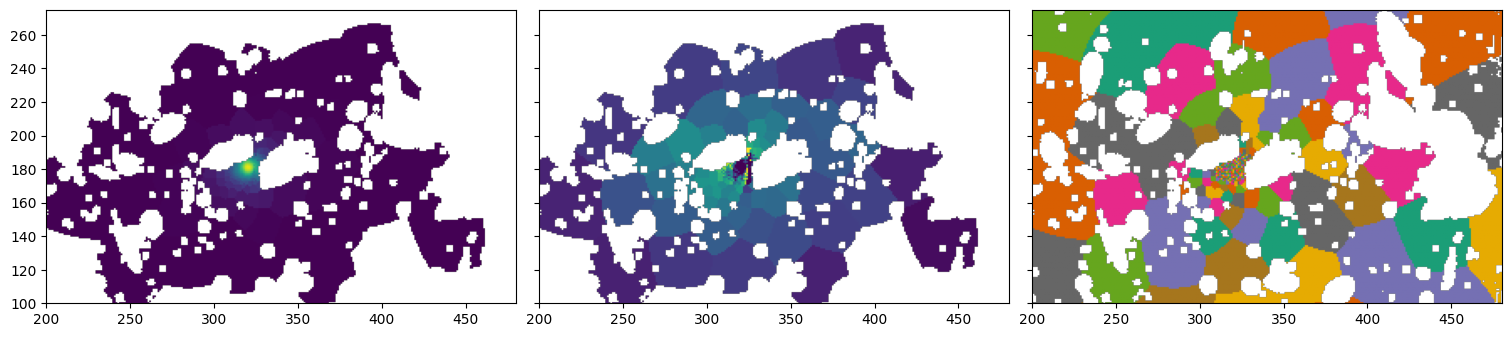

In [ ]:
fig, ax = plt.subplots(
    1, 3, figsize=(15, 5), sharex=True, sharey=True, layout="compressed"
)
ax[0].imshow(bcg_data, origin="lower", vmin=0, vmax=30)
ax[1].imshow(icl_data, origin="lower", vmin=0, vmax=3)
bins
ax[2].imshow(bins, origin="lower", cmap=seg_cmap)
ax[0].axis((200, 480, 100, 275));

In [ ]:
bcg_initial_params = {
    "center": [320, 180],
    "q": 0.6,
    "PA": 90 * np.pi / 180,
    "n": 2.0,
    "Re": 5.0,
    "Ie": 1.0,
}

## Binned fit with weights from component fraction

### Test

In [ ]:
test_params = {
    "center": [319, 179],
    "q": 0.7,
    "PA": 90 * np.pi / 180,
    "n": 1.2,
    "Re": 40.0,
    "Ie": 0.5,
}

In [ ]:
test_target = ap.image.Target_Image(
    data=np.zeros_like(bcg_data), mask=bcg_mask, bins=bins, pixelscale=1
)
test_model = ap.models.AstroPhot_Model(
    name="test_truth",
    model_type="sersic galaxy model",
    parameters=test_params,
    target=test_target,
)
test_model.initialize()

In [ ]:
test_data = test_model.sample().data.cpu()
test_noise = np.random.normal(size=test_data.shape)
test_data += test_noise

In [ ]:
test_target = ap.image.Target_Image(
    data=test_data, mask=bcg_mask, bins=bins, pixelscale=1
)
test_data_binned = test_target.unbinned_data.cpu()

In [ ]:
test_target, test_fit_model = fit(
    "test", test_data_binned, bcg_mask, None, bins, bcg_initial_params, n_bootstrap=0
)

In [ ]:
print(test_fit_model.parameters)
print(test_model.parameters)

test:
center: [319.0738830566406, 179.02627563476562] +- [0.09940408170223236, 0.06793902069330215] [arcsec]
q: 0.7015132308006287 +- 0.02108302339911461 [b/a], limits: (0.0, 1.0)
PA: 1.5532268285751343 +- 0.03843485563993454 [radians], limits: (0.0, 3.1415927410125732), cyclic
n: 1.1746478080749512 +- 0.042821627110242844 [none], limits: (0.36000001430511475, 8.0)
Re: 38.74175262451172 +- 2.666107416152954 [arcsec], limits: (0.0, None)
Ie: 0.5185702443122864 +- 0.02942102774977684 [log10(flux/arcsec^2)]
test_truth:
center: [319.0, 179.0] +- [0.10000000149011612, 0.10000000149011612] [arcsec]
q: 0.699999988079071 +- 0.029999999329447746 [b/a], limits: (0.0, 1.0)
PA: 1.5707963705062866 +- 0.05999999865889549 [radians], limits: (0.0, 3.1415927410125732), cyclic
n: 1.2000000476837158 +- 0.05000000074505806 [none], limits: (0.36000001430511475, 8.0)
Re: 40.0 [arcsec], limits: (0.0, None)
Ie: 0.5 [log10(flux/arcsec^2)]


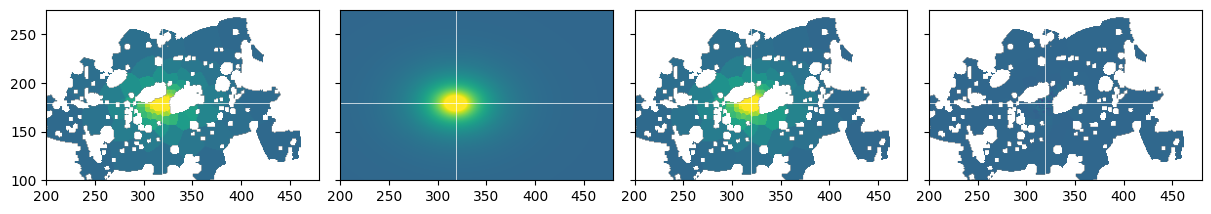

In [ ]:
plot_data_model_residual(
    test_target,
    test_fit_model,
    bcg_mask,
    weight=False,
    centre=test_model,
)

In [ ]:
test_weight = np.ones_like(test_data_binned)
test_target, test_fit_model_with_bootstrap = fit(
    "test_with_bootstrap",
    test_data_binned,
    bcg_mask,
    test_weight,
    bins,
    bcg_initial_params,
    n_bootstrap=25,
)
print(test_fit_model_with_bootstrap.parameters)
print(test_fit_model.parameters)
print(test_model.parameters)

test_with_bootstrap:
center: [319.0738220214844, 179.02635192871094] +- [0.09391791373491287, 0.07725222408771515] [arcsec]
q: 0.7015271782875061 +- 0.01827649399638176 [b/a], limits: (0.0, 1.0)
PA: 1.5532314777374268 +- 0.04102564975619316 [radians], limits: (0.0, 3.1415927410125732), cyclic
n: 1.1746844053268433 +- 0.029405344277620316 [none], limits: (0.36000001430511475, 8.0)
Re: 38.74308776855469 +- 1.3296222686767578 [arcsec], limits: (0.0, None)
Ie: 0.5185467600822449 +- 0.018410447984933853 [log10(flux/arcsec^2)]
test:
center: [319.0738830566406, 179.02627563476562] +- [0.09940408170223236, 0.06793902069330215] [arcsec]
q: 0.7015132308006287 +- 0.02108302339911461 [b/a], limits: (0.0, 1.0)
PA: 1.5532268285751343 +- 0.03843485563993454 [radians], limits: (0.0, 3.1415927410125732), cyclic
n: 1.1746478080749512 +- 0.042821627110242844 [none], limits: (0.36000001430511475, 8.0)
Re: 38.74175262451172 +- 2.666107416152954 [arcsec], limits: (0.0, None)
Ie: 0.5185702443122864 +- 0.0294

### Fit the BCG

In [ ]:
total = bcg_data + icl_data
bcg_weight = bcg_data / total
bcg_weight = np.clip(bcg_weight, 1e-6, 1 - 1e-6)
icl_weight = 1 - bcg_weight

# Scale weight to reflect expected variance
total_noise = total / snr_data
total_weight = 1 / total_noise**2
bcg_weight *= total_weight
icl_weight *= total_weight

In [ ]:
bcg_target, bcg_model = fit(
    "bcg", bcg_data, bcg_mask, bcg_weight, bins, bcg_initial_params
)

In [ ]:
bcg_model.parameters

bcg (id-15296761040, branch node):
  center (id-15296761520): [321.0885314941406, 181.4156494140625] +- [0.10554764419794083, 0.07839930057525635] [arcsec]
  q (id-15296760880): 0.8145323395729065 +- 0.013571594841778278 [b/a], limits: (0.0, 1.0)
  PA (id-15296763120): 1.6444435119628906 +- 0.059939127415418625 [radians], limits: (0.0, 3.1415927410125732), cyclic
  n (id-15296761680): 1.294454574584961 +- 0.05240555852651596 [none], limits: (0.36000001430511475, 8.0)
  Re (id-15296758480): 16.070762634277344 +- 0.6580805778503418 [arcsec], limits: (0.0, None)
  Ie (id-15296762800): 0.6535319685935974 +- 0.027230598032474518 [log10(flux/arcsec^2)]

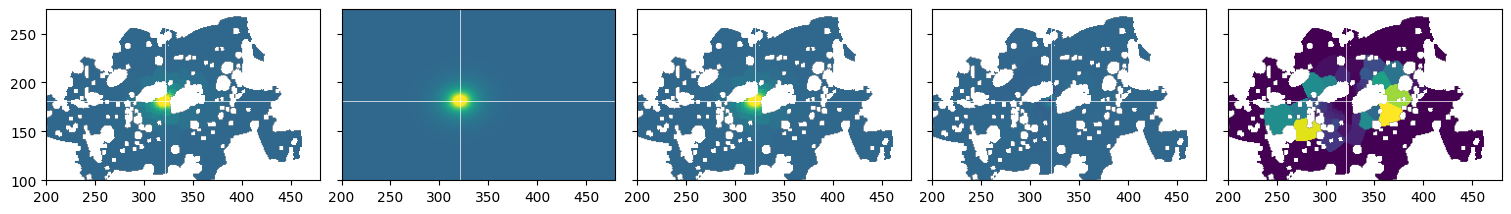

In [ ]:
plot_data_model_residual(bcg_target, bcg_model, bcg_mask, centre=bcg_model)

### Fit the ICL

In [ ]:
icl_initial_params = {
    "center": [320, 180],
    "q": 0.6,
    "PA": 90 * np.pi / 180,
    "n": 2.0,
    "Re": 20.0,
    "Ie": 0.5,
}

In [ ]:
icl_target, icl_model = fit(
    "icl", icl_data, icl_mask, icl_weight, bins, icl_initial_params
)

In [ ]:
icl_model.parameters

icl (id-15296738672, branch node):
  center (id-15296739472): [316.40325927734375, 183.7227325439453] +- [3.1388297080993652, 1.4447345733642578] [arcsec]
  q (id-15296736112): 0.6916739344596863 +- 0.055135179311037064 [b/a], limits: (0.0, 1.0)
  PA (id-15296736912): 1.7782626152038574 +- 0.06972695887088776 [radians], limits: (0.0, 3.1415927410125732), cyclic
  n (id-15296737712): 0.6679210662841797 +- 0.09626399725675583 [none], limits: (0.36000001430511475, 8.0)
  Re (id-15296737072): 71.6790771484375 +- 6.190029144287109 [arcsec], limits: (0.0, None)
  Ie (id-15296737392): -0.16646833717823029 +- 0.04987397789955139 [log10(flux/arcsec^2)]

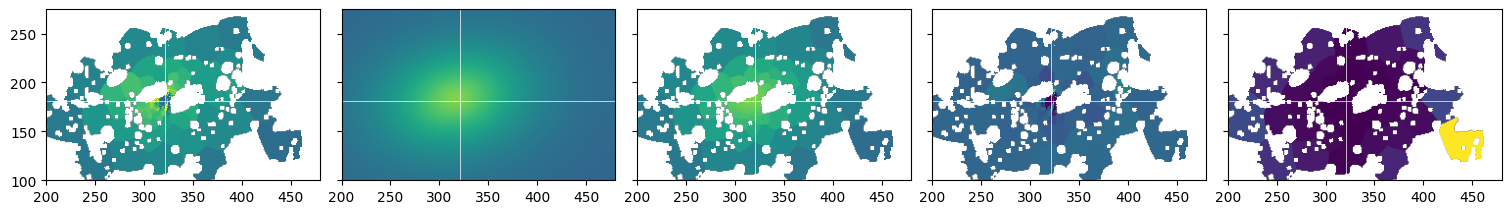

In [ ]:
plot_data_model_residual(icl_target, icl_model, icl_mask, centre=bcg_model)

### BCG-ICL offset

In [ ]:
bcg_center = bcg_model.parameters["center"].value.detach().cpu().numpy()
bcg_center_err = bcg_model.parameters["center"].uncertainty.detach().cpu().numpy()
icl_center = icl_model.parameters["center"].value.detach().cpu().numpy()
icl_center_err = icl_model.parameters["center"].uncertainty.detach().cpu().numpy()

In [ ]:
center_result = calculate_offset_uncertainty(
    bcg_center, bcg_center_err, icl_center, icl_center_err
)
center_offset = center_result["total_offset"]
center_offset_err = center_result["total_offset_uncertainty"]
print(f"Offset is {center_offset:.1f} ± {center_offset_err:.1f} pixels")

Offset is 5.2 ± 2.9 pixels


### Save the model

In [ ]:
with open(path / "bcg_model.pkl", "wb") as f:
    pickle.dump(bcg_model, f)
with open(path / "icl_model.pkl", "wb") as f:
    pickle.dump(icl_model, f)